In [1]:
#Load Feature Dataset
import pandas as pd

df = pd.read_csv("../data/processed/time_window_features.csv")
df.head()


,TransactionDT,TransactionAmt,customer_id,card1,card2,ProductCD,isFraud,txn_count_1h,txn_count_24h,txn_count_7d,avg_amt_1h,avg_amt_24h,avg_amt_7d,max_amt_24h,amount_dev_24h,std_amt_24h,amount_zscore_24h,hour,is_night_txn
0,1970-04-10 22:40:15,19.093,10003_555.0,10003,555.0,C,0,2.0,2.0,3.0,14.924,14.924000,23.080667,19.093,4.169000,5.895856,0.707107,22,0
1,1970-04-11 00:40:05,19.093,10003_555.0,10003,555.0,C,0,1.0,3.0,4.0,19.093,16.313667,22.083750,19.093,2.779333,4.813947,0.577350,0,1
2,1970-01-16 18:25:07,100.000,10004_529.0,10004,529.0,R,0,1.0,2.0,2.0,100.000,125.000000,125.000000,150.000,-25.000000,35.355339,-0.707107,18,0
3,1970-02-13 19:58:39,107.950,10004_529.0,10004,529.0,W,0,1.0,2.0,3.0,107.950,316.450000,736.133333,524.950,-208.500000,294.863528,-0.707107,19,0
4,1970-02-16 09:20:45,54.490,10004_529.0,10004,529.0,W,0,1.0,2.0,4.0,54.490,42.745000,179.597500,54.490,11.745000,16.609938,0.707107,9,0


In [2]:
df["velocity_risk"] = (
    df["txn_count_1h"] / (df["txn_count_24h"] + 1)
).clip(0, 1)


In [3]:
#Feature set
features = [
    "txn_count_1h",
    "txn_count_24h",
    "txn_count_7d",
    "avg_amt_1h",
    "avg_amt_24h",
    "avg_amt_7d",
    "max_amt_24h",
    "amount_zscore_24h",
    "is_night_txn",
    "velocity_risk"
]

X = df[features]
y = df["isFraud"]


In [4]:
#Train / Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [5]:
#Handle Class Imbalance
#Computing fraud ratio
fraud_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
fraud_ratio

np.float64(26.16650011530479)

In [ ]:
#compute
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 26.16650011530479


In [7]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [8]:
#inspect probability distribution
y_pred = model.predict_proba(X_test)[:,1]

print("Max probability:", y_pred.max())
print("Mean probability:", y_pred.mean())

Max probability: 0.9499972
Mean probability: 0.38951644


In [9]:
#Find Good Thresholds
import numpy as np
from sklearn.metrics import precision_recall_curve

y_scores = model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

for p, r, t in zip(precision[:10], recall[:10], thresholds[:10]):
    print(f"threshold={t:.2f}, precision={p:.2f}, recall={r:.2f}")

threshold=0.00, precision=0.04, recall=1.00
threshold=0.00, precision=0.04, recall=1.00
threshold=0.00, precision=0.04, recall=1.00
threshold=0.00, precision=0.04, recall=1.00
threshold=0.00, precision=0.04, recall=1.00
threshold=0.00, precision=0.04, recall=1.00
threshold=0.00, precision=0.04, recall=1.00
threshold=0.00, precision=0.04, recall=1.00
threshold=0.00, precision=0.04, recall=1.00
threshold=0.00, precision=0.04, recall=1.00


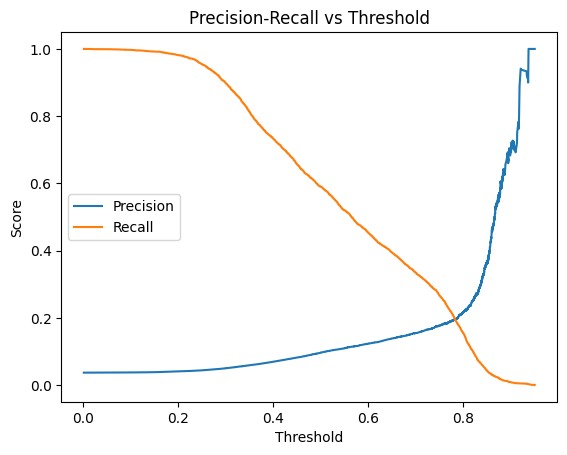

In [10]:
#Visualize Threshold Tradeoff
import matplotlib.pyplot as plt

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()

In [ ]:
#Define Fraud Policy

#High precision → block  -> BLOCK_THRESHOLD = 0.75
#High recall → investigate  -> INVESTIGATE_THRESHOLD = 0.40

In [12]:
#Evaluate Model
#ROC-AUC
from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC:", auc)


ROC-AUC: 0.7516072610227283


Average Precision: 0.14455803469148884


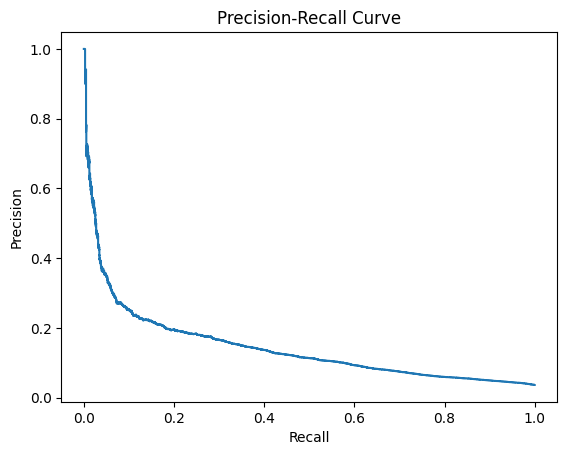

In [13]:
#Precision-Recall
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

ap = average_precision_score(y_test, y_pred_proba)
print("Average Precision:", ap)

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


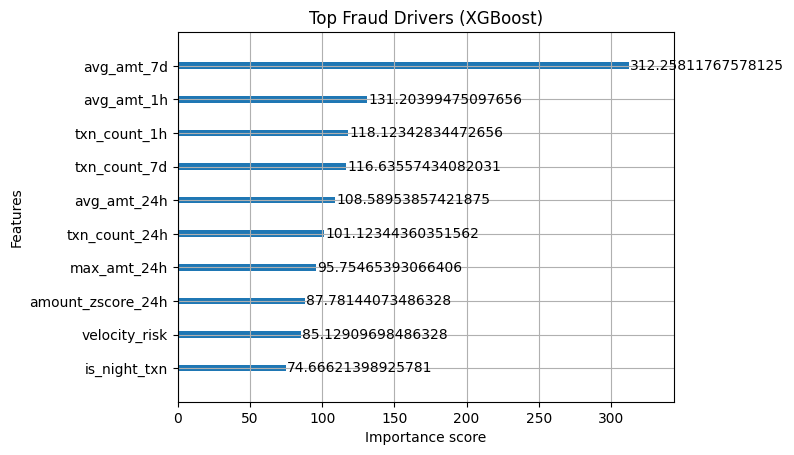

In [14]:
#Feature Importance (Explainability)
xgb.plot_importance(
    model,
    max_num_features=10,
    importance_type="gain"
)
plt.title("Top Fraud Drivers (XGBoost)")
plt.show()


In [15]:
#Save Model
import joblib

joblib.dump(model, "../models/xgb_fraud_model.pkl")


['../models/xgb_fraud_model.pkl']

In [16]:
#Sanity Check
pd.Series(y_pred_proba).describe()

count    88353.000000
mean         0.389516
std          0.174696
min          0.001786
25%          0.270878
50%          0.353686
75%          0.480888
max          0.949997
dtype: float64